<a href="https://colab.research.google.com/github/GinaldoDSSilva/ImersaoPythonAula/blob/main/C%C3%B3pia_de_%5BImers%C3%A3o_Python%5D_Aula_05.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [72]:
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from prophet import Prophet

O Prophet é uma ferramenta desenvolvida pelo Facebook para fazer previsões em séries temporais, que são basicamente dados coletados ao longo do tempo, como os preços das ações. É famoso por ser fácil de usar e por funcionar bem mesmo com poucos dados ou com dados que possuem padrões irregulares, o que é comum no mercado de ações.

Vamos usar dados de ações da empresa Johnson & Johnson como exemplo.

Aqui, usamos um comando para baixar os dados. É como se estivéssemos pedindo à internet para nos dar os preços das ações da Johnson & Johnson desde 2020 até o final de 2023. Fácil, né?

In [73]:
# Baixar dados dos últimos quatro anos para uma ação específica
dados = yf.download("JNJ", start="2020-01-01", end="2023-12-31", progress=False)
dados = dados.reset_index()
dados

Price,Date,Close,High,Low,Open,Volume
Ticker,,JNJ,JNJ,JNJ,JNJ,JNJ
0,2020-01-02,127.064163,127.107690,126.289435,126.977110,5777000
1,2020-01-03,125.593071,126.541893,124.478856,124.914096,5752400
2,2020-01-06,125.436409,125.523449,124.348307,125.349356,7731300
3,2020-01-07,126.202393,126.611520,123.068667,125.358025,7382900
4,2020-01-08,126.184982,127.072864,125.088167,126.106629,6605800
...,...,...,...,...,...,...
1001,2023-12-22,150.689316,151.726472,150.262816,150.485754,3798500
1002,2023-12-26,151.348434,151.551997,150.098028,150.243419,4170000
1003,2023-12-27,151.552017,151.716799,150.650549,150.728096,5288100


Agora, dividimos nossos dados em duas partes: uma para treinar nosso 'adivinho' digital, que é até julho de 2023, e outra para testar nossas previsões, que é o restante do ano.

In [74]:
# Vamos dividir os dados em treino (até o final do primeiro semestre de 2023) e teste (segundo semestre de 2023)
dados_treino = dados[dados['Date'] < '2023-07-31']
dados_teste = dados[dados['Date'] >= '2023-07-31']

In [75]:
# Preparando os dados para o FBProphet
dados_prophet_treino = dados_treino[['Date', 'Close']].rename(columns={'Date': 'ds', 'Close': 'y'})
dados_prophet_treino

Price,ds,y
Ticker,,JNJ
0,2020-01-02,127.064163
1,2020-01-03,125.593071
2,2020-01-06,125.436409
3,2020-01-07,126.202393
4,2020-01-08,126.184982
...,...,...
894,2023-07-24,163.326721
895,2023-07-25,164.577347
896,2023-07-26,164.892365


In [76]:
print(dados_prophet_treino.head())
print(dados_prophet_treino.columns)
print(dados_prophet_treino.dtypes)

Price          ds           y
Ticker                    JNJ
0      2020-01-02  127.064163
1      2020-01-03  125.593071
2      2020-01-06  125.436409
3      2020-01-07  126.202393
4      2020-01-08  126.184982
MultiIndex([('ds',    ''),
            ( 'y', 'JNJ')],
           names=['Price', 'Ticker'])
Price  Ticker
ds               datetime64[ns]
y      JNJ              float64
dtype: object


In [77]:
# Remover MultiIndex e renomear as colunas corretamente
dados_prophet_treino.columns = dados_prophet_treino.columns.get_level_values(-1)

# Renomear as colunas para os nomes esperados pelo Prophet
dados_prophet_treino = dados_prophet_treino.rename(columns={'': 'ds', 'JNJ': 'y'})

# Converter 'ds' para formato de data e 'y' para numérico
dados_prophet_treino['ds'] = pd.to_datetime(dados_prophet_treino['ds'])
dados_prophet_treino['y'] = pd.to_numeric(dados_prophet_treino['y'], errors='coerce')

# Verificar se a estrutura está correta agora
print(dados_prophet_treino.head())
print(dados_prophet_treino.dtypes)


Ticker         ds           y
0      2020-01-02  127.064163
1      2020-01-03  125.593071
2      2020-01-06  125.436409
3      2020-01-07  126.202393
4      2020-01-08  126.184982
Ticker
ds    datetime64[ns]
y            float64
dtype: object


In [78]:
# Resetar completamente o índice para remover qualquer resquício de MultiIndex
dados_prophet_treino = dados_prophet_treino.reset_index(drop=True)

# Verificar e ajustar os nomes das colunas corretamente
dados_prophet_treino.columns = ['ds', 'y']

# Converter 'ds' para formato de data e 'y' para numérico (caso necessário)
dados_prophet_treino['ds'] = pd.to_datetime(dados_prophet_treino['ds'])
dados_prophet_treino['y'] = pd.to_numeric(dados_prophet_treino['y'], errors='coerce')

# Exibir a estrutura final
print(dados_prophet_treino.head())
print(dados_prophet_treino.dtypes)


          ds           y
0 2020-01-02  127.064163
1 2020-01-03  125.593071
2 2020-01-06  125.436409
3 2020-01-07  126.202393
4 2020-01-08  126.184982
ds    datetime64[ns]
y            float64
dtype: object


O próximo passo é preparar os dados para o nosso adivinho, o Prophet. É como se estivéssemos arrumando os dados para que ele entenda o que estamos perguntando.

Depois, criamos o modelo do Prophet. Aqui, estamos dizendo ao Prophet para considerar padrões semanais e anuais nos dados, mas não diários. E também adicionamos feriados dos EUA, já que eles podem influenciar o preço das ações.

In [79]:
modelo = Prophet(weekly_seasonality=True, yearly_seasonality=True, daily_seasonality=False)
modelo.add_country_holidays(country_name='US')
modelo.fit(dados_prophet_treino)


DEBUG:cmdstanpy:input tempfile: /tmp/tmpb2tlooql/syago6s6.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpb2tlooql/5_new9ki.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=76017', 'data', 'file=/tmp/tmpb2tlooql/syago6s6.json', 'init=/tmp/tmpb2tlooql/5_new9ki.json', 'output', 'file=/tmp/tmpb2tlooql/prophet_modeljnaiqrf7/prophet_model-20250212204633.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
20:46:33 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
20:46:33 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


Agora, a parte mágica! Pedimos ao Prophet para prever o futuro, até o final de 2023. E então, plotamos um gráfico para ver como nossa previsão se compara com os dados reais.

In [80]:
# Criar datas futuras para previsão até o final de 2023
futuro = modelo.make_future_dataframe(periods=150)
previsao = modelo.predict(futuro)

Neste gráfico, vocês verão três linhas. A azul mostra o preço real das ações até julho de 2023, a verde mostra os preços reais após essa data, e a laranja mostra o que o Prophet previu. A linha vermelha pontilhada marca onde começam as previsões.

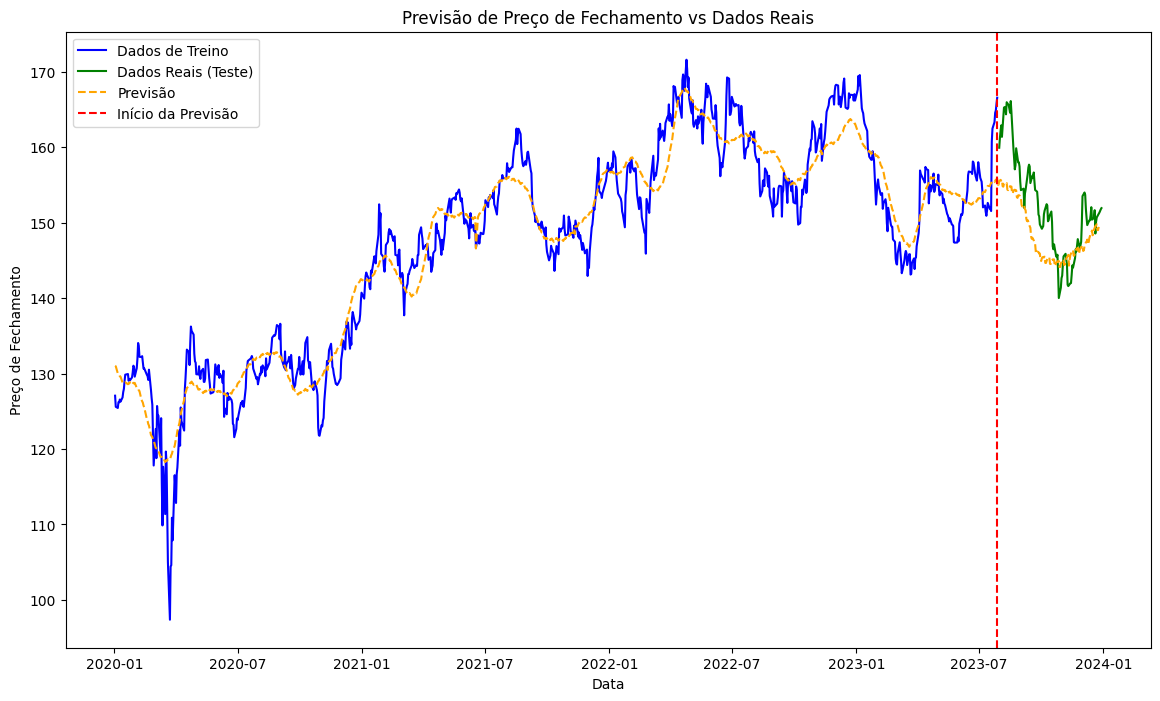

In [81]:
# Plotar os dados de treino, teste e previsões
plt.figure(figsize=(14, 8))
plt.plot(dados_treino['Date'], dados_treino['Close'], label='Dados de Treino', color='blue')
plt.plot(dados_teste['Date'], dados_teste['Close'], label='Dados Reais (Teste)', color='green')
plt.plot(previsao['ds'], previsao['yhat'], label='Previsão', color='orange', linestyle='--')

plt.axvline(dados_treino['Date'].max(), color='red', linestyle='--', label='Início da Previsão')
plt.xlabel('Data')
plt.ylabel('Preço de Fechamento')
plt.title('Previsão de Preço de Fechamento vs Dados Reais')
plt.legend()
plt.show()